# MIDI measurewise — per-measure lilylet / MIDI inspection

Reads a MIDI-measurewise dataset from a **config file** (`CondMidiPatchy` / `cond-midi.lmmw.pt`),
picks a **random sample**, picks a **random measure number** in it, then pulls out and decodes
the lilylet patches AND the midi event patches that belong to that measure — the lilylet side by
its own measure index `j`, the midi side by its lilylet-aligned `src_measure` (so a repeated
section's midi still lines up with the right lilylet measure).

Test config: `configs/midi-measurewise.yaml` (local `test20260629`).

In [1]:
from pathlib import Path
import sys, os

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'starry').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import random
import torch

from starry.utils.config import Configuration
from starry.lilylet.data.patchifier import LilyletTokenizer
from starry.midi.tokenizer import MidiTokenizer
from starry.midi.data.condPatchy import _get_store

# --- choose the config + where its data.root lives (DATA_DIR base) ---
CONFIG = str(REPO_ROOT / 'configs' / 'midi-measurewise.yaml')
DATA_DIR = str(Path.home() / 'data')
SEED = 25  # set to None for a fresh random sample/measure each run
print('config:', CONFIG)

config: /home/camus/work/deep-starry/configs/midi-measurewise.yaml


## 1. Resolve the dataset root from the config and open the store

In [2]:
config = Configuration.createOrLoad(CONFIG, volatile=True)
assert config['data.type'] == 'CondMidiPatchy', f"expected CondMidiPatchy, got {config['data.type']}"

ROOT = os.path.join(DATA_DIR, config['data.root'])
print('data.root :', config['data.root'])
print('resolved  :', ROOT)
print('exists    :', os.path.exists(ROOT))

store = _get_store(ROOT)
print('items     :', len(store))
print('tokenizers:', store.artifact['tokenizers'])

data.root : lilylet/midi-measurewise/test20260629/cond-midi.lmmw.pt
resolved  : /home/camus/data/lilylet/midi-measurewise/test20260629/cond-midi.lmmw.pt
exists    : True
items     : 215
tokenizers: {'lyl': {'vocab_size': 256}, 'midi': {'vocab_size': 41}}


## 2. Random sample + random measure

A sample's `measures` is each patch's OWN measure (lilylet `j` / midi `i`); `src_measures` is the
lilylet-aligned measure (lilylet: own `j`; midi: `source_measure(i)`). We pick a measure number
that exists on the lilylet side, then select lilylet patches by own-measure and midi patches by
`src_measure` — so under expanded repeats a played midi measure maps to its lilylet source measure.

In [3]:
rng = random.Random(SEED)

EX = rng.randrange(len(store))
item = store.get(EX)
mod = item['modality']
own = item['measures'].long()
src = item['src_measures'].long()
L = int(item['lyl_count'])
T = item['patches'].shape[0]

# lilylet body measures present in this sample (own measure > 0 on the lyl side)
lyl_measures = sorted(set(int(m) for m in own[:L].tolist() if m > 0))
MEAS = rng.choice(lyl_measures)

print(f'sample #{EX}: id={item["id"]}')
print(f'  T={T}  lyl_count L={L}  midi patches={T - L}  M_lyl={item["M_lyl"]}  M_midi={item["M_midi"]}')
print(f'  lilylet body measures: {lyl_measures[0]}..{lyl_measures[-1]} ({len(lyl_measures)} measures)')
print(f'  >>> picked measure number: {MEAS}')

sample #96: id=20250409_154614_Classical_Schubert, Franz_Chamber_postinst
  T=4309  lyl_count L=660  midi patches=3649  M_lyl=109  M_midi=109
  lilylet body measures: 1..109 (109 measures)
  >>> picked measure number: 99


## 3. Decode the lilylet patches of measure `MEAS`

In [4]:
lt = LilyletTokenizer(str(REPO_ROOT / 'assets' / 'lilylet-tokenizer.json'))
mt = MidiTokenizer()
patches = item['patches'].long()

def decode_lyl_patch(row):
    toks = [lt.text_by_id.get(int(t), '?') for t in row if int(t) not in (lt.pad_id, lt.bos_id, lt.eos_id)]
    return ''.join(toks)

# lilylet patches whose OWN measure == MEAS (lilylet segment: positions < L)
lyl_rows = [i for i in range(L) if int(own[i]) == MEAS]
print(f'lilylet patches for measure {MEAS}: {len(lyl_rows)} patches (rows {lyl_rows[0]}..{lyl_rows[-1]})\n')
lyl_text = ''.join(decode_lyl_patch(patches[i]) for i in lyl_rows)
print('--- decoded lilylet (concatenated patches) ---')
print(lyl_text)

lilylet patches for measure 99: 6 patches (rows 596..601)

--- decoded lilylet (concatenated patches) ---
[r:98/10]\key bf \major \time 2/4 f'8 f f c'16( af \\\
ef8 c'16( af f8) f \\\
r8 af af r |



## 4. Decode the MIDI event patches aligned to measure `MEAS`

Midi patches whose lilylet-aligned `src_measure == MEAS`. Under expanded repeats a lilylet
measure can map to MORE than one played midi measure (it was repeated), so we also show the
midi patches' own measure `i` to make the repeat visible.

In [5]:
# midi patches (positions >= L) whose src_measure == MEAS
midi_rows = [i for i in range(L, T) if int(src[i]) == MEAS]
midi_own = sorted(set(int(own[i]) for i in midi_rows))
print(f'midi patches with src_measure=={MEAS}: {len(midi_rows)} patches')
print(f'  -> played midi measure(s): {midi_own}' + ('  (repeated!)' if len(midi_own) > 1 else '') + '\n')

print(f'--- decoded MIDI events (src_measure=={MEAS}) ---')
for i in midi_rows:
    line = mt.decode_event(patches[i].tolist())
    tag = '<eom>' if int(patches[i, 0]) == mt.eom_id else ''
    print(f'  [row {i:5d}] midi_meas={int(own[i]):>3} {tag:5} {line!r}')

midi patches with src_measure==99: 37 patches
  -> played midi measure(s): [99]

--- decoded MIDI events (src_measure==99) ---
  [row  3924] midi_meas= 99       'note_on 1 0 4d 31'
  [row  3925] midi_meas= 99       'control_change 0 0 2 31'
  [row  3926] midi_meas= 99       'note_on 0 1 3f 31'
  [row  3927] midi_meas= 99       'control_change 0 1 2 31'
  [row  3928] midi_meas= 99       'note_off ef 0 4d'
  [row  3929] midi_meas= 99       'note_off 0 1 3f'
  [row  3930] midi_meas= 99       'note_on 1 0 4d 31'
  [row  3931] midi_meas= 99       'control_change 0 0 2 31'
  [row  3932] midi_meas= 99       'note_on 0 1 48 31'
  [row  3933] midi_meas= 99       'control_change 0 1 2 31'
  [row  3934] midi_meas= 99       'note_on 0 2 38 31'
  [row  3935] midi_meas= 99       'control_change 0 2 2 31'
  [row  3936] midi_meas= 99       'note_off 77 1 48'
  [row  3937] midi_meas= 99       'note_on 1 1 44 31'
  [row  3938] midi_meas= 99       'control_change 0 1 2 31'
  [row  3939] midi_meas= 99    

## 5. Side-by-side summary

In [6]:
print(f'sample #{EX}  ({item["id"]})')
print(f'measure {MEAS}:')
print(f'  lilylet : {len(lyl_rows)} patch(es)')
print(f'  midi    : {len(midi_rows)} patch(es) across played measure(s) {midi_own}')
print()
print('lilylet:')
print('  ' + lyl_text.replace(chr(10), chr(10) + '  '))
print('midi events:')
for i in midi_rows:
    print('  ' + mt.decode_event(patches[i].tolist()))

sample #96  (20250409_154614_Classical_Schubert, Franz_Chamber_postinst)
measure 99:
  lilylet : 6 patch(es)
  midi    : 37 patch(es) across played measure(s) [99]

lilylet:
  [r:98/10]\key bf \major \time 2/4 f'8 f f c'16( af \\\
  ef8 c'16( af f8) f \\\
  r8 af af r |
  
midi events:
  note_on 1 0 4d 31
  control_change 0 0 2 31
  note_on 0 1 3f 31
  control_change 0 1 2 31
  note_off ef 0 4d
  note_off 0 1 3f
  note_on 1 0 4d 31
  control_change 0 0 2 31
  note_on 0 1 48 31
  control_change 0 1 2 31
  note_on 0 2 38 31
  control_change 0 2 2 31
  note_off 77 1 48
  note_on 1 1 44 31
  control_change 0 1 2 31
  note_off 77 0 4d
  note_off 0 1 44
  note_off 0 2 38
  note_on 1 0 4d 31
  control_change 0 0 2 31
  note_on 0 1 41 31
  control_change 0 1 2 31
  note_on 0 2 38 31
  control_change 0 2 2 31
  note_off ef 0 4d
  note_off 0 1 41
  note_off 0 2 38
  note_on 1 0 54 31
  control_change 0 0 2 31
  note_on 0 1 41 31
  control_change 0 1 2 31
  note_off 77 0 54
  note_on 1 0 50 31
  

## 6. Onset scatter: lilylet vs MIDI (measure `MEAS`)

Each note's onset is **normalized within the measure** (0 = barline, 1 = next barline) on the
x-axis, with MIDI **pitch number** on the y-axis, so the lilylet and MIDI notes overlay directly.
Lilylet onsets come from the lilylet AST server (`tools/astServer.ts`: parses the source, walks
voices accumulating duration, returns per-note onset + MIDI pitch). MIDI onsets are reconstructed
from the packed event patches' deltaTimes, normalized by the measure's tick span.

Start the server first (from the lilylet repo): `npx tsx tools/astServer.ts --port 8788`

In [7]:
import json, urllib.request

AST_SERVER = 'http://127.0.0.1:8788'

# The packed store holds token ids, not the original lilylet source; the AST server needs
# source text. Locate the sample's .lyl beside the dataset (config data.root's dir has lyl/).
ds_dir = os.path.dirname(ROOT)
lyl_src = os.path.join(ds_dir, 'lyl', item['id'] + '.lyl')
print('lyl source:', lyl_src, '| exists:', os.path.exists(lyl_src))

def query_onsets(code):
    req = urllib.request.Request(AST_SERVER + '/onsets',
        data=json.dumps({'code': code}).encode(), headers={'Content-Type': 'application/json'})
    return json.load(urllib.request.urlopen(req, timeout=30))

with open(lyl_src, encoding='utf-8') as f:
    lyl_code = f.read()
resp = query_onsets(lyl_code)
assert resp['ok'], resp.get('error')
mrec = next((m for m in resp['measures'] if m['index'] == MEAS), None)
assert mrec is not None, 'measure %d not in AST onsets' % MEAS

# flatten to (onsetNorm, midi_pitch) points (chords -> one point per pitch)
lyl_points = [(n['onsetNorm'], p) for n in mrec['notes'] for p in n['midi']]
print('lilylet measure %d: timeSig=%s measureDivisions=%s notes=%d onset-points=%d' % (
    MEAS, mrec['timeSig'], mrec['measureDivisions'], len(mrec['notes']), len(lyl_points)))
for n in mrec['notes'][:8]:
    print('  onsetNorm=%.3f midi=%s staff=%s grace=%s' % (n['onsetNorm'], n['midi'], n['staff'], n['grace']))

lyl source: /home/camus/data/lilylet/midi-measurewise/test20260629/lyl/20250409_154614_Classical_Schubert, Franz_Chamber_postinst.lyl | exists: True


lilylet measure 99: timeSig={'numerator': 2, 'denominator': 4} measureDivisions=8 notes=12 onset-points=12
  onsetNorm=0.000 midi=[77] staff=1 grace=False
  onsetNorm=0.250 midi=[77] staff=1 grace=False
  onsetNorm=0.500 midi=[77] staff=1 grace=False
  onsetNorm=0.750 midi=[84] staff=1 grace=False
  onsetNorm=0.875 midi=[80] staff=1 grace=False
  onsetNorm=0.000 midi=[63] staff=1 grace=False
  onsetNorm=0.250 midi=[72] staff=1 grace=False
  onsetNorm=0.375 midi=[68] staff=1 grace=False


midi onset-points for src_measure==99 (played measures [99]): 12


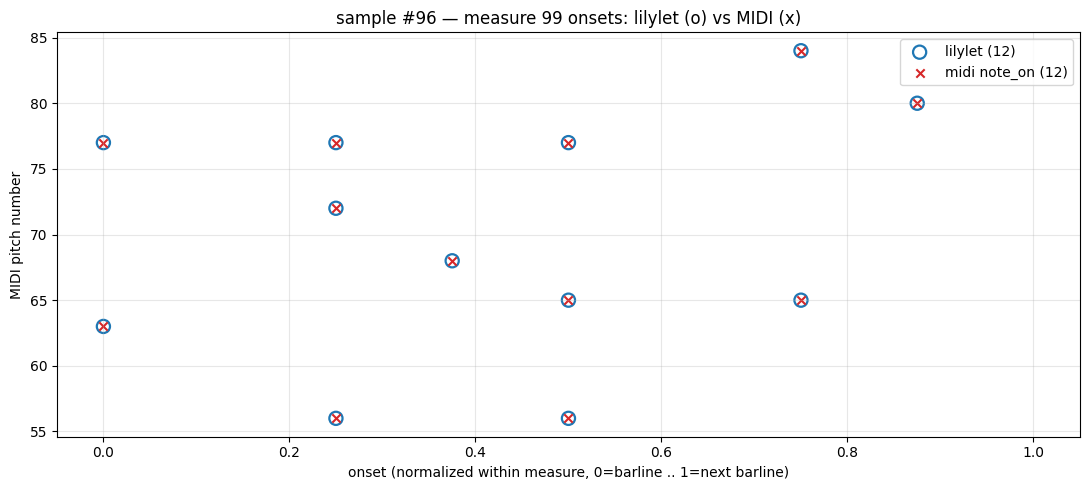

In [8]:
get_ipython().run_line_magic('matplotlib', 'inline')
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline', force=True)
import matplotlib.pyplot as plt

# --- reconstruct absolute tick per midi patch by accumulating deltaTime over the whole
#     midi segment (events are in time order), then bucket note_on onsets by OWN measure. ---
midi_seg = list(range(L, T))
abst = 0
per_measure_onsets = {}     # own measure -> list of (abs_tick, midi_pitch)
measure_first_tick = {}     # own measure -> smallest abs_tick seen
for i in midi_seg:
    line = mt.decode_event(patches[i].tolist())
    if not line or int(patches[i, 0]) == mt.eom_id:
        # eom carries no deltaTime; skip (measure boundary marker)
        continue
    parts = line.split()
    if len(parts) < 2:
        continue
    try:
        delta = int(parts[1], 16)
    except ValueError:
        delta = 0
    abst += delta
    mi = int(own[i])
    measure_first_tick.setdefault(mi, abst)
    if parts[0] == 'note_on' and len(parts) >= 5:
        try:
            vel = int(parts[4], 16)
        except ValueError:
            vel = 0
        if vel > 0:
            pitch = int(parts[3], 16)
            per_measure_onsets.setdefault(mi, []).append((abst, pitch))

# the target lilylet measure maps (via src_measure) to played midi measure(s) `midi_own`.
# normalize each played measure's note_on ticks by that measure's [start, next-start) span.
sorted_measures = sorted(measure_first_tick)
def measure_span(mi):
    start = measure_first_tick[mi]
    nxt = [measure_first_tick[m] for m in sorted_measures if measure_first_tick[m] > start]
    end = min(nxt) if nxt else max((t for pts in per_measure_onsets.values() for t, _ in pts), default=start + 1)
    return start, max(end, start + 1)

midi_points = []            # (onsetNorm, midi_pitch)
for mi in midi_own:         # played measure(s) for this lilylet measure
    start, end = measure_span(mi)
    span = end - start
    for t, pitch in per_measure_onsets.get(mi, []):
        midi_points.append(((t - start) / span, pitch))
print(f'midi onset-points for src_measure=={MEAS} (played measures {midi_own}): {len(midi_points)}')

# --- plot: lilylet vs midi onsets, normalized x in [0,1], MIDI pitch on y ---
fig, ax = plt.subplots(figsize=(11, 5))
if lyl_points:
    lx, ly = zip(*lyl_points)
    ax.scatter(lx, ly, s=90, marker='o', facecolors='none', edgecolors='tab:blue', linewidths=1.6, label=f'lilylet ({len(lyl_points)})')
if midi_points:
    mx, my = zip(*midi_points)
    ax.scatter(mx, my, s=36, marker='x', color='tab:red', label=f'midi note_on ({len(midi_points)})')
ax.set_xlabel('onset (normalized within measure, 0=barline .. 1=next barline)')
ax.set_ylabel('MIDI pitch number')
ax.set_title(f'sample #{EX} — measure {MEAS} onsets: lilylet (o) vs MIDI (x)')
ax.set_xlim(-0.05, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
plt.tight_layout(); plt.show()